In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from scipy.stats.stats import pearsonr
import sklearn as sk
from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
# novelty analysis
from sklearn.neighbors import LocalOutlierFactor
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [36]:
df = pd.read_excel ('Mobile info.xlsx') #for an earlier version of Excel, you may need to use the file extension of 'xls'

In [37]:
df.head(4)

,Product_Name,Seller_Name,Overall_Rating,Overall_Review,Seller_Rating,Average_Rating,Product_Quality
0,RedmiNote6Pro,FlashstarCommerce,352708,32857,4.7,4.4,Excellent
1,RedmiNote6Pro,SuperComNet,352708,32857,4.3,4.1,Excellent
2,RedmiNote7,SuperComNet,10387,1057,4.3,4.6,Excellent
3,RedmiY1,samaymobiles,17421,1634,3.1,3.7,Good


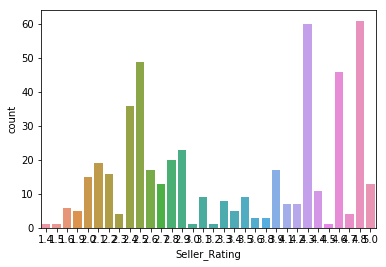

<Figure size 1080x648 with 0 Axes>

In [43]:
sns.countplot(df['Seller_Rating'],label="Count")
plt.figure(figsize=(15,9))
plt.savefig('M_Seller')
plt.show()

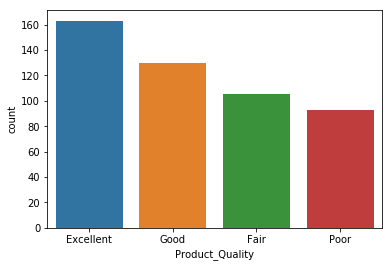

In [33]:
sns.countplot(df['Product_Quality'],label="Count")
plt.savefig('Product Quality')
plt.show()

In [34]:

labelencoder = LabelEncoder()
df['Product_Name'] = labelencoder.fit_transform(df['Product_Name'])
df['Seller_Name'] = labelencoder.fit_transform(df['Seller_Name'])
df['Product_Quality'] = labelencoder.fit_transform(df['Product_Quality'])


In [7]:
df['Seller_Rating']= df['Seller_Rating'].astype('category')
df['Seller_Rating'] = df['Seller_Rating'].cat.codes
df['Average_Rating']= df['Average_Rating'].astype('category')
df['Average_Rating'] = df['Average_Rating'].cat.codes
df['Overall_Rating']= df['Overall_Rating'].astype('category')
df['Overall_Rating'] = df['Overall_Rating'].cat.codes
df['Overall_Review']= df['Overall_Review'].astype('category')
df['Overall_Review'] = df['Overall_Review'].cat.codes

In [8]:
df.head()

,Product_Name,Seller_Name,Overall_Rating,Overall_Review,Seller_Rating,Average_Rating,Product_Quality
0,11,16,96,87,29,30,0
1,77,7,96,87,25,27,0
2,78,7,62,40,25,32,0
3,79,14,71,45,15,24,2
4,11,16,89,75,25,29,0


In [9]:
feature_cols = ['Seller_Name', 'Seller_Rating', 'Overall_Review', 'Overall_Rating','Average_Rating']
X = df[feature_cols] # Features
y = df.Product_Quality # Target variable

In [10]:
df.head(2)

,Product_Name,Seller_Name,Overall_Rating,Overall_Review,Seller_Rating,Average_Rating,Product_Quality
0,11,16,96,87,29,30,0
1,77,7,96,87,25,27,0


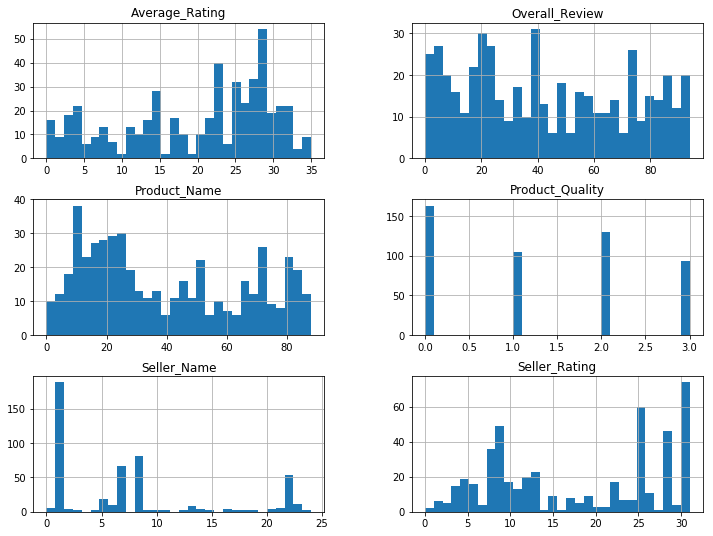

In [11]:
import pylab as pl
df.drop('Overall_Rating' ,axis=1).hist(bins=30, figsize=(12,9))
plt.savefig('M_Review')
plt.show()

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


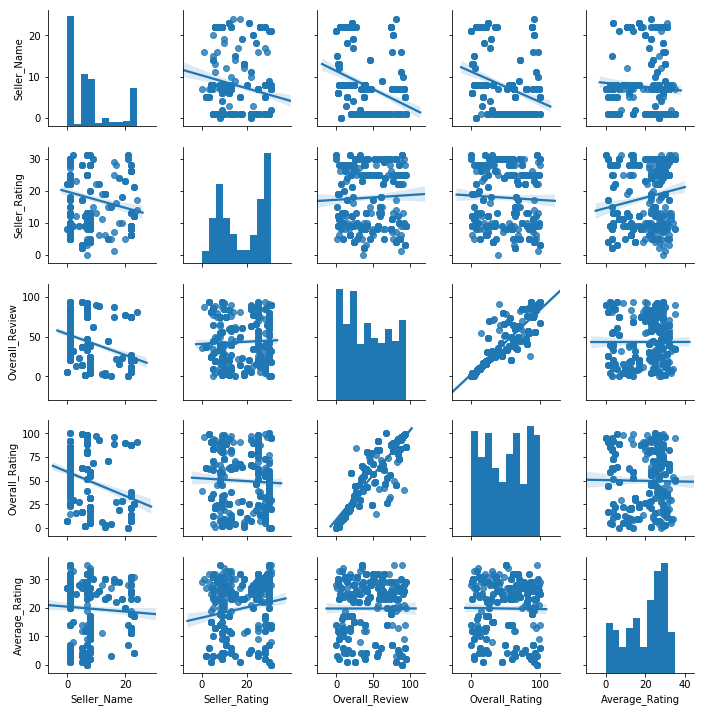

<Figure size 432x288 with 0 Axes>

In [13]:
sns.pairplot(X,kind='reg',height=2)
plt.show()
plt.savefig('Mobile_correlation among different attributes')

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0) # 70% training and 30% test

In [15]:

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
results=confusion_matrix(y_test,y_pred)
print('confusion matrix')
print(results)
print (classification_report(y_test,y_pred))

Accuracy: 1.0
confusion matrix
[[49  0  0  0]
 [ 0 36  0  0]
 [ 0  0 39  0]
 [ 0  0  0 24]]
             precision    recall  f1-score   support

          0       1.00      1.00      1.00        49
          1       1.00      1.00      1.00        36
          2       1.00      1.00      1.00        39
          3       1.00      1.00      1.00        24

avg / total       1.00      1.00      1.00       148



In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0) # 70% training and 30% test

In [17]:
from sklearn.ensemble import RandomForestClassifier

#Create a Gaussian Classifier
clf=RandomForestClassifier(n_estimators=100)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
results=confusion_matrix(y_test,y_pred)
print('confusion matrix')
print(results)
print (classification_report(y_test,y_pred))

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\ensemble\weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d


Accuracy: 0.9932432432432432
confusion matrix
[[49  0  0  0]
 [ 0 36  0  0]
 [ 0  1 38  0]
 [ 0  0  0 24]]
             precision    recall  f1-score   support

          0       1.00      1.00      1.00        49
          1       0.97      1.00      0.99        36
          2       1.00      0.97      0.99        39
          3       1.00      1.00      1.00        24

avg / total       0.99      0.99      0.99       148



In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0) # 70% training and 30% testa

In [19]:
from sklearn import svm

#Create a svm Classifier
clf = svm.SVC(kernel='rbf' ,gamma='auto') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
results=confusion_matrix(y_test,y_pred)
print('confusion matrix')
print(results)
print (classification_report(y_test,y_pred))

Accuracy: 0.8513513513513513
confusion matrix
[[48  0  1  0]
 [ 5 31  0  0]
 [16  0 23  0]
 [ 0  0  0 24]]
             precision    recall  f1-score   support

          0       0.70      0.98      0.81        49
          1       1.00      0.86      0.93        36
          2       0.96      0.59      0.73        39
          3       1.00      1.00      1.00        24

avg / total       0.89      0.85      0.85       148



In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1) # 70% training and 30% testa

In [21]:
from sklearn.naive_bayes import GaussianNB

#Create a Gaussian Classifier
gnb = GaussianNB()

#Train the model using the training sets
gnb.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = gnb.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
results=confusion_matrix(y_test,y_pred)
print('confusion matrix')
print(results)
print (classification_report(y_test,y_pred))

Accuracy: 0.9662162162162162
confusion matrix
[[43  0  2  0]
 [ 0 38  0  1]
 [ 2  0 32  0]
 [ 0  0  0 30]]
             precision    recall  f1-score   support

          0       0.96      0.96      0.96        45
          1       1.00      0.97      0.99        39
          2       0.94      0.94      0.94        34
          3       0.97      1.00      0.98        30

avg / total       0.97      0.97      0.97       148



In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1) # 70% training and 30% testa

In [23]:
#import the KNeighborsClassifier class from sklearn
from sklearn.neighbors import KNeighborsClassifier
#import metric model to check the accuracy
from sklearn import metrics
#Try running from k=1 through 5 and record testing accuracy
k_range = range(1,5)

score = {}

score_list = []
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train,y_train)
        y_pred=knn.predict(X_test)
        score[k] = metrics.accuracy_score(y_test,y_pred)
        score_list.append(metrics.accuracy_score(y_test,y_pred))
# Model Accuracy: how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
results=confusion_matrix(y_test,y_pred)
print('confusion matrix')
print(results)
print (classification_report(y_test,y_pred))

Accuracy: 0.8243243243243243
confusion matrix
[[36  0  9  0]
 [ 0 37  1  1]
 [10  2 22  0]
 [ 0  3  0 27]]
             precision    recall  f1-score   support

          0       0.78      0.80      0.79        45
          1       0.88      0.95      0.91        39
          2       0.69      0.65      0.67        34
          3       0.96      0.90      0.93        30

avg / total       0.82      0.82      0.82       148

